In [304]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

<font size="6" color="red">ch10. 파일 N차원배열다루기</font>
- N차원 배열 객체 : 동일 자료형의 집합
- 독립변수 : 원인(내가 바꾸는 것) / 종속변수 : 원인으로 인해 변하는 것(결과)
- 1차원: 단순한 리스트 [' ']
- 2차원: 리스트안에 리스트가 있는 형태 (행과 열) [ [' '] ]
- 3차원: 리스트 안에 리스트 안에 리스트 (층, 행, 열) [[ [' '] ]]
- 4차원: 리스트 안에 리스트 안에 리스트 안에 리스트 (데이터 묶음, 층, 행, 열) [[[ [' '] ]]]
- [numpy](https://numpy.org) - LMM 관련 정보는 Gpt가 제일 거짓말을 많이하므로, 신뢰할만한 출처 사이트
- [numpy API Docs](https://numpy.org/doc/stable/reference/index.htm1) - 새로운 함수에 대한 정보
# 1절. 넘파이 패키지

In [108]:
import numpy as np
np.__version__ # tensorflow==2.10과 맞는 numpy 버전

'1.23.5'

In [109]:
# np.arange(from,stop,by) : from부터 stop앞까지 by씩 증가하는 1차원 정수 배열
a = np.arange(15)
print(a.shape) #  a 몇차원인지 확인하는 명령어  ->  15열짜리 1차원 배열
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.1 배열속성
- 배열 생성 -> 변수 = arange(생성할 숫자 갯수).reshape(행, 열)
- 변수.size = 원소의 개수
- 변수.dtype = dtype('int비트') -> 1Byte = 8bit
- 변수.itemsize = 요소 하나의 메모리(byte)사이즈
- 변수.dtype = np.int64 -> int 수정전 -> int64로 변경
- itemsize의 계산 = int64 ÷ 8 = 8bit = itemsize는 8

In [110]:
from numpy import arange 
a = arange(15, 
                       # dtype=np.int8
                        ).reshape(3, 5) # -> (3행 5열로 변환)해라
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [111]:
# 복습
from numpy import arange # import : 다른 파일에 있는 기능을 현재 파일에서 사용할 수 있도록 가져오는 키워드.
ex_a = arange(24).reshape(3, 8)
ex_a

array([[ 0,  1,  2,  3,  4,  5,  6,  7],
       [ 8,  9, 10, 11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20, 21, 22, 23]])

In [112]:
type(a) # a변수의 타입

numpy.ndarray

In [113]:
ex_a.dtype # a배열의 요소(item)들의 type

dtype('int32')

In [114]:
ex_a.dtype.name

'int32'

In [115]:
ex_a.itemsize # 한 요소(item)의 byte size

4

In [116]:
ex_a.ndim # 축수 (차원수)

2

In [117]:
ex_a.shape # 배열 구조(2차원 3행5열)

(3, 8)

In [118]:
a.shape = (3,5) # 3행 5열 조정전
print('shape 조정전 a:\n', a)
a.shape = (5,3) # 5행 3열로 조정후
print('shape 조정후 a:\n', a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


In [119]:
a.reshape(3, 5)

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [120]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

## 1.2 배열 타입 변경

In [121]:
# 배열 요소의 타입변경(부적절한 예시)
a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [122]:
# 요소갯수
a.size

12

In [123]:
# 32bit씩 읽겠다
a.dtype

dtype('int32')

In [124]:
a.itemsize

4

In [125]:
a.dtype = np.int64
a.dtype

dtype('int64')

In [126]:
# 요소의 byte수
a.itemsize

8

In [127]:
a

array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [128]:
# 요소 갯수
a.size

6

In [129]:
# 배열 요소의 타입변경(올바른 예시)
a = arange(15).reshape(5, 3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [130]:
# a의 타입을 변경해라 -> 64비트로
# a.astype(np.int64) # 출력할 경우 -> a가 바뀌지 않음. / 출력X -> a바뀜
a = a.astype(np.int64)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [131]:
a.dtype

dtype('int64')

In [132]:
a.itemsize

8

In [133]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [134]:
a.ravel() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

In [135]:
a.flatten() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

## 1.3 배열 저장
- pkl(객체저장, 배열, 머신러닝 모델 저장) vs npy(넘파이 전용포맷, io개선)

In [136]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [137]:
%%time
import time
start = time.time() # 1970.1.1부터 지금까지의 초수
with open('data/ch10.pkl', 'wb') as f:
    pickle.dump(a, f)
end = time.time()
print('실행 시간 :', (end-start))

NameError: name 'pickle' is not defined

In [138]:
%%time
with open('data/ch10.pkl', 'rb') as f:
    loaded_a = pickle.load(f)

NameError: name 'pickle' is not defined

In [139]:
# a ==(파일저장)==> 피클파일(269B) ==(Load)==> Loaded_a
loaded_a

NameError: name 'loaded_a' is not defined

In [140]:
%%time
np.save('data/ch11.npy', a) #넘파이전용포맷. 빠르고 효율적 안전

CPU times: total: 0 ns
Wall time: 1 ms


In [141]:
%%time
loaded_a2 = np.load('data/ch11.npy')

CPU times: total: 0 ns
Wall time: 1.93 ms


In [142]:
# a ==(저장)==> npy(248B) == (Load) ==> Loaded_a2
loaded_a2

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

# 2절. 넘파이배열
- array()함수를 이용한 다른 파이썬 데이터구조(list, tup)를 배열변환
- 특정값을 갖는 배열 생성함수 : arange, ones, zeros, full, empty.....
- 랜덤값을 갖는 배열 생성함수 ~......
- [넘파이함수들](https://numpy.org/doc/stable/reference/index.html)
## 2.1 array()함수로 넘파이 배열 만들기
- array(리스트나 튜플 object, dtype=np.type, copy=T/F)
- array(obj, dtype='type', copy=T/F)
type 예 : int16, int32, float16, float32, float64, ...

In [143]:
a = np.array([2, 14, 6]
                     # dtype=np.int16
                  ) # 정수의 기본 타입은 int32/실수의 기본타입은 float64
a, a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [144]:
a[0], a[1], a[2]

(2, 14, 6)

In [145]:
for item in a:
    print(item, end='\t')

2	14	6	

In [146]:
b = np.array([[1.5, 2.3],   # 동일자료형의 집합으로 배열 생성 : 정수>실수>문자
                      [4, 5]])        # 실수 배열의 기본타입 : float64
b

array([[1.5, 2.3],
       [4. , 5. ]])

In [147]:
b.dtype

dtype('float64')

In [148]:
l = [[1.5, 2.3],[4,5]]
l[0][1]

2.3

In [149]:
b[0,1] # 2차원 [axis0=행, axis1=열] cf. 1차원[axis0=열]

2.3

In [150]:
a = np.array([[1.5, 2.3],
                     [4,5]],
             # dtype="float32"
             dtype=np.float32
                     ).reshape(2,2) # )뒤에.reshape(행, 열) 가능
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [151]:
a.dtype

dtype('float32')

In [152]:
# a의 배열 구조 변경
a.shape = (2,2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [153]:
# a의 dtype(요소의 타입) 변경
# 부적절한 예시) a.dtype = np.float16
a = a.astype(np.float16)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float16)

In [154]:
l = [[1.5, 2.3],
    [4,5]]
for row in l: # for문의 row는 행을 하나씩 가져온다.
    for item in row: # 해당 for문은 row 안의 요소(item)를 하나씩 가져온다.
        print(item, end=' ')
    print()

1.5 2.3 
4 5 


In [155]:
for i, row in enumerate(l):   # enumaerate()는 반복문에서 인덱스(번호)와 값을 동시에 가져오는 함수. -> 1 사과 / 2 바나나
    for j, item in enumerate(row):
        print(f"{i}행{j}열 : {l[i][j]}", end='\t')
        print()

0행0열 : 1.5	
0행1열 : 2.3	
1행0열 : 4	
1행1열 : 5	


In [156]:
for i, row in enumerate(l):
    for j, item in enumerate(row):
        print(f"{i}행{j}열 : {a[i,j]}", end='\t') # float16은 소수점 이하 불안정
    print()

0행0열 : 1.5	0행1열 : 2.30078125	
1행0열 : 4.0	1행1열 : 5.0	


In [157]:
print(b[0,0]) # 인덱싱
# print(b[0,2]) 없는 인덱싱은 에러

1.5


In [158]:
# 슬라이싱 from:stop:by, 0행:끝행, 1열부터 10열전까지 슬라이싱(행과 열 모두 슬라이싱 2차원 배열)
b[0:, 1:10]

array([[2.3],
       [5. ]])

In [159]:
b[0:1, 1:3] # 0행, 1열부터 3열 전까지 슬라이싱(열만 슬라이싱 1차원 배열)

array([[2.3]])

In [160]:
b = np.array([[1,2,3],
                      [6,7,8]])
b[:, -1:], b[:, -1]
# 모든 행의 마지막 열만 추출

(array([[3],
        [8]]),
 array([3, 8]))

In [161]:
# 모든 행의 마지막 열을 제외한 부분 추출
b = np.array([[1,2,3],
                      [6,7,8]])
b[:, :-1]

array([[1, 2],
       [6, 7]])

In [162]:
# 스칼라 변수
a = 10 # 원본
b = a  # 복제본
print("a={}, b={}, a주소={}, b주소={}".format(a, b, id(a), id(b)))
b = -1
print("a={}, b={}, a주소={}, b주소={}".format(a, b, id(a), id(b)))

a=10, b=10, a주소=2489109905936, b주소=2489109905936
a=10, b=-1, a주소=2489109905936, b주소=2489109905584


In [163]:
# numpy 배열
c = np.array([[-1, 2], [3,4]], dtype=np.uint16) # uint는 양수로 처리해서 계산 / int는 양수 음수 둘 다 가능
d = np.array(c, copy=False) # d = c 동일 # 할당
# int8 = 부호가 들어가기때문에 최대 경우의 수가 256(0~255까지)이므로 -와 + 둘다 처리하게되면 -128 ~ +127만 표현가능
# uint8는 부호가 없기때문에 8비트 전부를 숫자로 표현 가능하므로, 0 ~ 255 표현 가능
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(d), id(d))

c=
[[65535     2]
 [    3     4]]
d=
[[65535     2]
 [    3     4]]
두 변수의 주소 : 2489280198288 2489280198288
c=
[[9 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2489280198288 2489280198288


In [164]:
c = np.array([[-1, 2], [3,4]], dtype=np.uint16) # uint는 양수로 처리해서 계산 / int는 양수 음수 둘 다 가능
d = np.array(c, copy=True) # d = c.copy()와 동일 # 깊은 복사
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(d), id(d))

c=
[[65535     2]
 [    3     4]]
d=
[[65535     2]
 [    3     4]]
두 변수의 주소 : 2489280198480 2489280198576
c=
[[65535     2]
 [    3     4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2489280198576 2489280198576


In [165]:
# copy=False해도 깊은 복사가 되는 경우 : dtype이 바뀌면 자동 깊은 복사
c = np.array([[-1, 2], [3,4]],    dtype=np.int16) # -> 원본 uint는 양수로 처리해서 계산 / int는 양수 음수 둘 다 가능 
d = np.array(c, copy=False,  dtype=np.int32)
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(d), id(d))

c=
[[-1  2]
 [ 3  4]]
d=
[[-1  2]
 [ 3  4]]
두 변수의 주소 : 2489280198384 2489280198480
c=
[[-1  2]
 [ 3  4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2489280198480 2489280198480


## 2.2 기본값이 있는 배열 만들기
- np.zeros(tup [,dtype] ) : 요소들이 다 0.0
- np.ones( tup [,dtype] ) : 요소들이 다 1.0
- np.full( tup, 기본값) : 요소들이 다 두번째 매개변수인 기본값
- np.emtpy(tup) : 초기 내용은 임의의 값인 배열(메모리 상태에 따라 달라짐)

※ 위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64. dtype속성을 따로 지정할 수 있음

In [166]:
np.zeros( (3, 5) ) # 3행동5열짜리 2차원 float64 배열 (요소들은 다 0)
np.zeros( (5,) )

array([0., 0., 0., 0., 0.])

In [167]:
x = np.zeros ( (2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print()

[[False False False False False]
 [False False False False False]]
bool



In [168]:
np.ones( (3, 5) ) # 3행5열짜리 2차원 float64 배열(요소들은 다 1)
np.ones( (5,)   ) # 5열짜리 1차원 float64 배열(요소들은 다 1)
np.ones( 5 ) # 5열짜리 1차원 float64 배열(요소들은 다 1)

array([1., 1., 1., 1., 1.])

In [169]:
x = np.ones( (2, 5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


In [170]:
x = np.full( (2,5), 255 )
print(x)
print(x.dtype)

[[255 255 255 255 255]
 [255 255 255 255 255]]
int32


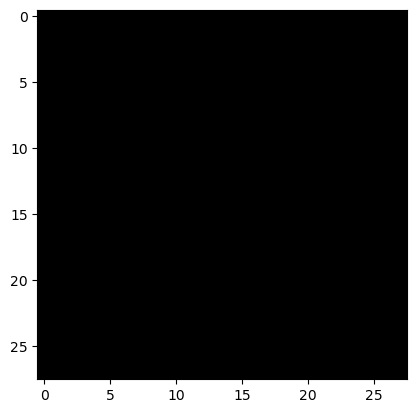

In [171]:
import matplotlib.pyplot as plt
img = np.full( (28,28), 255, dtype=np.uint8) # 하얀색
img = np.full( (28,28), 200, dtype=np.uint8) # 회색
img = np.zeros( (28,28), dtype=np.uint8) # 검정색
#plt.figure(figsize=(1,1))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
# plt.axis('off')
plt.show()

In [172]:
import numpy as np
np.empty( (3, 2) )

array([[0.37472222, 0.33722222],
       [0.37472222, 4.03322222],
       [4.07072222, 0.33722222]])

## 2.3 랜덤값을 갖는 배열 만들기

※ n차원 배열 만들기

- np.random.random( tup ) : 0부터 1미만의 균등분포를 갖은 tup 사이즈 랜덤값
- np.random.uniform(low=0, high=1.0, size=tup) : low부터 high미만까지 균등분포를 갖는 랜덤값
- np.random.normal(loc=0.0, scale=1.0, size=tup) : 평균loc, 표준편차scale을 갖는 정규분포 랜덤값

※ 1차원 배열 만들기

- np.random.rand(n) : 균등분포의 1차원 0~1미만 난수 배열 발생(난수가 n개)
- np.random.randn(n) : 표준정규분포(평균0, 표준편차가1인 정규분포)의 1차원 난수 배열 발생(난수 n개)

※ 난수 1개 만들기

- np.random.randint(n) : 0부터 n미만의 정수 난수 1개발생 == random.randint(0, n-1)
- np.random.randint(from, to) : from부터 to미만의 정수 난수 1개발생 == random.randint(from,to-1)

### 용어 설명
- *균등분포 : 모든 곳에서 확률이 균등하게(똑같이) 나타나는 분포
- *난수 : 무작위로 추출된 숫자
- *정규분포 : 평균 근처에 데이터가 가장 많이 몰려있고, 양끝으로 갈수록 대칭을 이루며 완만하게 줄어드는 형태

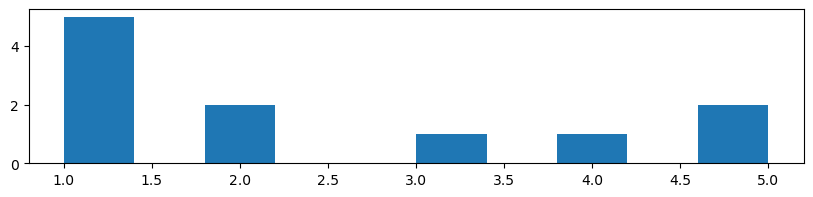

In [173]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = [1, 2, 3, 1, 1, 1, 2, 1, 4, 5, 5]
plt.hist(x, bins=10)
plt.show()

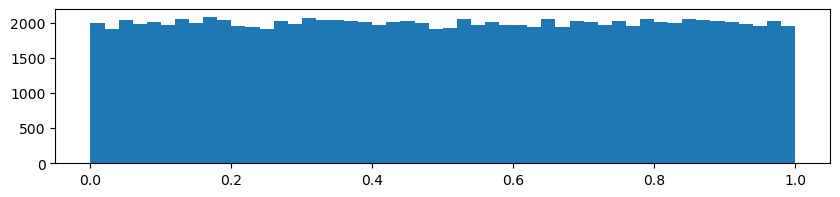

In [174]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
# x = np.random.random(1000000)
# x = np.random.uniform(1, 10, 10000000)
x = np.random.rand(100000)
plt.hist(x, bins=50)
plt.show()

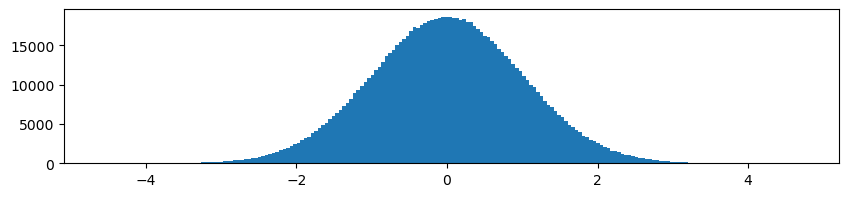

In [175]:
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.normal(50, 10, 1000000) # 정규분포
x = np.random.normal(0, 1, 1000000) # 표준정규분포
x = np.random.randn(1000000)# 표준정규분포
plt.hist(x, bins=200)
plt.show()

In [192]:
# 2차원 균등분포 난수(0~1미만 실수 난수) 배열
import numpy as np
# np.random.seed(3) seed값을 맞추면 발생되는 난수가 동일. seed값을 초기화하려면 커널 재시작
np.random.random( (2, 5) ) # 2행5열짜리 2차원 난수 배열

array([[0.73357088, 0.66809011, 0.49447638, 0.92847199, 0.01039843],
       [0.51940315, 0.04714534, 0.70693007, 0.2655855 , 0.29342079]])

In [193]:
# 2차원 균등분포 난수(-1~1미만 실수 난수) 배열
np.random.uniform(-1, 1, (2,5)) # 2행5열짜리 배열

array([[ 0.78567887,  0.72417824,  0.71654183,  0.27189283,  0.90329249],
       [-0.9309194 , -0.64504946,  0.50517531, -0.90266887, -0.30899214]])

In [194]:
# 2차원 정규분포 난수(평균 3에 표준편차1인 난수) 배열
np.random.normal(3,1, (1,5)) # 1행 5열 2차원 배열

array([[3.54690848, 4.23783392, 3.20703735, 4.44814861, 3.00000352]])

In [195]:
# 1차원 균등분포 난수 배열 
np.random.rand(3) # (1차원만 가능)
np.random.random(3) # 위의 입력값과 동일하되, 위의 명령어는 1차원만 가능하며, 해당 명령어는 여러 차원가능

array([0.91165466, 0.97335507, 0.43792004])

In [196]:
# 1차원 표준정규분포(평균 0, 표준편차1인 정규분포) 배열
np.random.randn(3)
np.random.normal(size=3)

array([-0.19092335,  0.75880521,  0.10826145])

## 2.4 연속된 값을 갖는 배열 만들기
- np.arange(from, to, by, dtype) : from부터 to앞까지 by씩 건너뛴 값을 1차원 배열로 생성
- np.linspace(from, to, num) : from부터 to(to 포함)까지 num개 숫자들을 1차원 배열로 생성

### np.arange(from, to, by, dtype) : from부터 to앞까지 by씩 건너뛴 값을 1차원 배열로 생성

In [197]:
np.arange(10, 30, 5, dtype=np.float32)

array([10., 15., 20., 25.], dtype=float32)

In [204]:
np.arange(0, 3, 0.3)

array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7])

### np.linspace(from, to, num) : from부터 to(to 포함)까지 num개 숫자들을 1차원 배열로 생성

In [210]:
np.linspace(0, 3, 20) # 0부터 3까지(3 포함) 같은 간격으로 20개 수를 배열

array([0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895,
       0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263,
       1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632,
       2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ])

In [211]:
np.linspace(0, 3, 20).reshape(4,5)

array([[0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895],
       [0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263],
       [1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632],
       [2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ]])

In [226]:
x = np.array([0,1,2,3,4,5,6])
# linspace : 특정 구간에 많은 수의 점을 생성할 때 유용
x = np.linspace(0, 6, 10)
y = np.sin(x)

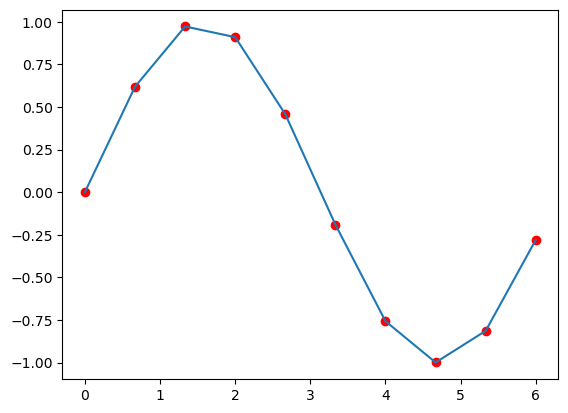

In [227]:
# import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
plt.scatter(x,y,c='r') # 빨간색 점그래프
plt.plot(x, y) #선 그래프
plt.show()

## 2.5 배열의 차원 변경
- reshape(행수, 열수) : -1 가능
- resize( (행수, 열수) ) : -1 불가
- rave1(), flatten() : 1차원으로 변경된 배열 return
- T : 전치행렬로 변환된 배열을 return
- transpose() : 전치행렬로 변환된 배열을 return
※실행결과가 출력되면 배열이 수정되지 않고, 실행결과가 없으면 배열이 수정됨. but, 배열이 수정되지 않았다면 return된 것.

In [404]:
t = np.random.random( (2,5) )
print(t)
print(t*10)

[[0.73504767 0.57014922 0.53009134 0.61351158 0.71217974]
 [0.17544517 0.56236252 0.40458285 0.30187963 0.9301857 ]]
[[7.35047665 5.70149216 5.30091345 6.13511578 7.12179736]
 [1.7544517  5.62362521 4.04582846 3.01879628 9.30185698]]


In [405]:
t * 10 # 배열은 곱하면 요소별 연산
# round(9.6) : 스칼라 값을 반올림(배열은 안됨)
a = np.round(t*10)
a

array([[7., 6., 5., 6., 7.],
       [2., 6., 4., 3., 9.]])

In [406]:
a = a.astype(np.int16) # astype()을 이용한 요소별 타입 변환
a # 2행5열 = 차원변경

array([[7, 6, 5, 6, 7],
       [2, 6, 4, 3, 9]], dtype=int16)

### a.reshape()

In [407]:
a.reshape(5, 2)

array([[7, 6],
       [5, 6],
       [7, 2],
       [6, 4],
       [3, 9]], dtype=int16)

In [408]:
a.reshape(5, -1) # -1이 주어지면 해당 차원의 크기가 자동계산 a의 item이 10일때 5행으로 하면 2열로 자동 계산

array([[7, 6],
       [5, 6],
       [7, 2],
       [6, 4],
       [3, 9]], dtype=int16)

In [409]:
a.reshape (-1, 2) # -1은 자주 쓰이며, a값 reshape을 저장하고싶다면 a = 할당해줘야함

array([[7, 6],
       [5, 6],
       [7, 2],
       [6, 4],
       [3, 9]], dtype=int16)

In [410]:
a.resize ((2,5)) # a를 바꿈
a.resize(2,5)
a

array([[7, 6, 5, 6, 7],
       [2, 6, 4, 3, 9]], dtype=int16)

### a.resize()
- a.resize(-1) # resize함수에는 -1 불가

In [415]:
a.resize ((2,5)) # a를 바꿈
a.resize(2,5)
a

array([[7, 6, 5, 6, 7],
       [2, 6, 4, 3, 9]], dtype=int16)

In [424]:
a.ravel()

array([7, 6, 5, 6, 7, 2, 6, 4, 3, 9], dtype=int16)

In [425]:
a.flatten()

array([7, 6, 5, 6, 7, 2, 6, 4, 3, 9], dtype=int16)

In [426]:
a

array([[7, 6, 5, 6, 7],
       [2, 6, 4, 3, 9]], dtype=int16)

### a.T  / a.transpose()

In [427]:
a.T # a의 전치행렬(행과 열을 뒤바꾼 행렬 ex. 0행1열 -> 1행0열)

array([[7, 2],
       [6, 6],
       [5, 4],
       [6, 3],
       [7, 9]], dtype=int16)

In [428]:
a.transpose() # a의 전치행렬

array([[7, 2],
       [6, 6],
       [5, 4],
       [6, 3],
       [7, 9]], dtype=int16)

## 2.6 배열 인쇄

In [429]:
print(np.arange(100).reshape(10,10))

[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]
 [60 61 62 63 64 65 66 67 68 69]
 [70 71 72 73 74 75 76 77 78 79]
 [80 81 82 83 84 85 86 87 88 89]
 [90 91 92 93 94 95 96 97 98 99]]


In [430]:
print(np.arange(1001)) # item 갯수가 1000개까지만 나옴. 그 이상은 출력값이 생략됨.

[   0    1    2 ...  998  999 1000]


In [431]:
np.arange(10000).reshape(100, 100)

array([[   0,    1,    2, ...,   97,   98,   99],
       [ 100,  101,  102, ...,  197,  198,  199],
       [ 200,  201,  202, ...,  297,  298,  299],
       ...,
       [9700, 9701, 9702, ..., 9797, 9798, 9799],
       [9800, 9801, 9802, ..., 9897, 9898, 9899],
       [9900, 9901, 9902, ..., 9997, 9998, 9999]])

In [432]:
np.get_printoptions()['threshold'] # 출력되는 limit

1000

In [433]:
# 배열이 너무 커서 인쇄할 수 없는 경우 자동으로 건너뛰고 끝 부분만 출력
# 넘파이의 인쇄 옵션 변경 (인쇄할 사이즈를 조정)
np.set_printoptions(threshold=10000) # 배열 10000개까지 출력하도록 옵션 세팅
# np.arange(10000).reshape(100, 100) 이제 10000까지는 다 출력됨. 너무 길어서 주석처리함.
np.set_printoptions(threshold=np.inf) # np.inf : 무한대
import sys
np.set_printoptions(threshold=sys.maxsize)

In [434]:
sys.maxsize

9223372036854775807

In [435]:
# 커널을 재시작하거나
import numpy as np
np.set_printoptions(threshold=1000)
np.arange(10000).reshape(100, 100)

array([[   0,    1,    2, ...,   97,   98,   99],
       [ 100,  101,  102, ...,  197,  198,  199],
       [ 200,  201,  202, ...,  297,  298,  299],
       ...,
       [9700, 9701, 9702, ..., 9797, 9798, 9799],
       [9800, 9801, 9802, ..., 9897, 9898, 9899],
       [9900, 9901, 9902, ..., 9997, 9998, 9999]])

## 2.7 기본 연산 동작
### 1) 배열의 요소별 연산

In [436]:
a = np.array([10, 20, 30, 40], dtype=np.int8)
b = np.arange(4)
print(a) # 배열을 print에 넣으면 array와 , (쉼표)가 안나옴
print(b)

[10 20 30 40]
[0 1 2 3]


In [437]:
c = a+b # 요소별 +연산 (dtype은 큰 것으로, 정수와 실수연산은 실수로)
print(c)
print(c.dtype)

[10 21 32 43]
int32


In [438]:
a ** 2

array([ 100, -112, -124,   64], dtype=int8)

In [439]:
a * b # 요소별 연산시 dtype이 큰 쪽인 int32로 되어서 출력가능

array([  0,  20,  60, 120])

In [440]:
a ** b

array([    1,    20,   900, 64000], dtype=int32)

In [441]:
a < 40

array([ True,  True,  True, False])

In [442]:
print(a[ [0,1,2,3] ]) # ( [[ ]] ) -> index를 list로
print(a[ [ True, True, True, False] ]) # boolean index를 출력한다면 처음부터 끝까지 입력값을 다 넣어야함.
print(a [ [0, 2] ])

[10 20 30 40]
[10 20 30]
[10 30]


In [443]:
# a배열에서 40미만인 데이터만 추출하려면 boolean index 사용
a[a<40]

array([10, 20, 30], dtype=int8)

In [444]:
# a배열에서 40미만인 데이터의 index
np.where(a<40)

(array([0, 1, 2], dtype=int64),)

### 2) 행렬의 곱(@,dot함수) cf. *(요소별 곱)
- 2차원 배열은 행렬로 취급
- pdf 18page

#### 용어정리
- *행렬 : 2차원으로 숫자들을 가로와 세로로 정렬해 놓은 숫자 표

In [445]:
A = np.array([[1, 1],
                       [0, 1]])
B = np.array([[2, 0],
                       [3, 4]])
A, B

(array([[1, 1],
        [0, 1]]),
 array([[2, 0],
        [3, 4]]))

In [446]:
print('요소별 곱 A*B=' , A*B, sep='\n') # sep= '중간에 \n 다음줄로 넘기겠다'
print('행렬 곱 A@B =', A@B, sep="\n")
print("행렬 곱 A.dot(B) =", A.dot(B), sep="\n")

요소별 곱 A*B=
[[2 0]
 [0 4]]
행렬 곱 A@B =
[[5 4]
 [3 4]]
행렬 곱 A.dot(B) =
[[5 4]
 [3 4]]


### 행렬의 곱
- 핵심 규칙 : 앞 행렬의 열 개수와 뒤 행렬의 행 개수가 반드시 같아야함 (2 x 3)행렬과 (3 x 4) = (2 x 4) 행렬이 됨 
- A@B = 행렬의 A와 행렬B를 곱한 값
- a@단위행렬 == 단위행렬@a : 단위행렬에서는 행렬곱의 교환법칙이 성립됨.

In [447]:
a = np.array([[1, 2],
                       [3, 4]])
b = np.array([[-1, -1],
                       [1, 1]])
print( a@b, b@a, sep="\n")

[[1 1]
 [1 1]]
[[-4 -6]
 [ 4  6]]


In [448]:
a = np.array([[1,2],
                       [3,4]])
b = np.array([[6],
                       [7]])
print(a@b) # 2x2 @2x1 = 2x1
# m행 r열 @ r행 n열 =? m행 n열

[[20]
 [46]]


In [449]:
a = np.array([[1,2,3],
                       [3, 4, 1]])
b = np.array([[0,0],
                       [1,1],
                       [-1, 2]])
print(a@b) # 2x3 @ 3x2 = 2x2
print(b@a) # 3x2 @ 2x3 = 3x3

[[-1  8]
 [ 3  6]]
[[ 0  0  0]
 [ 4  6  4]
 [ 5  6 -1]]


### 0713 오늘의 핵심

In [450]:
# a@단위행렬 == 단위행렬@a : 단위행렬에서는 행렬곱의 교환법칙이 성립됨.
# 단위 행렬은 정방행렬
A = np.array([[1,0],
                      [0,1]]) # 2행 2열짜리 단위행렬
B = 

SyntaxError: invalid syntax (4033446381.py, line 5)

In [451]:
# 2행2열 단위행렬
np.eye(2)

array([[1., 0.],
       [0., 1.]])

### 3) 복합 대입 연산자 사용(+=, -=, ...)
- 배열에서는 a += b는 a = a+b와 다소 다르게 작동

In [487]:
a = np.ones( (2,3), dtype='int8') # int8 범위 -128~127 / 8비트로 만들수있는 경우의 수는 256 / unit 범위 = 0~255
b = np.random.random( (2,3) ) # float64
print(a, b)

[[1 1 1]
 [1 1 1]] [[0.37974763 0.43758614 0.68195421]
 [0.6487251  0.14645336 0.12881589]]


In [488]:
a[0,0] = 128
a

array([[-128,    1,    1],
       [   1,    1,    1]], dtype=int8)

In [453]:
a += 5 # a = a+5
a

array([[6, 6, 6],
       [6, 6, 6]], dtype=int8)

In [454]:
a += 255 # 공간이 부족하면
a

array([[5, 5, 5],
       [5, 5, 5]], dtype=int8)

In [455]:
a = a+255 # a+255를 요소별로 계산하여 새로운 a배열을 생성하여 할당
a

array([[260, 260, 260],
       [260, 260, 260]], dtype=int16)

In [456]:
b += a # b+a를 기존의 b에 넣는다
b

array([[260.38265839, 260.37233287, 260.29972766],
       [260.00584909, 260.31160696, 260.86034326]])

In [457]:
a += b # a+b(float64)를 기존의 a에 넣는다
a

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int16') with casting rule 'same_kind'

In [458]:
# 스칼라 데이터에서는 문제되지 않음
x = 5
y = 5.7
x += y
x

10.7

### 4) 배열 요소별 집계
- sum, min, max, mean, var(분산), std(표준편차)

In [489]:
a = np.array([[2, 2, 2, 3],
                       [4, 3, 2, 1]])

In [490]:
print('전체 합 :', a.sum(), np.sum(a))
print('전체 최소값 :', a.min(), np.min(a))
print('전체 최대값 :', a.max(), np.max(a))
print('전체 평균 :', a.mean(), np.mean(a))
print('전체 분산 :', a.var(), np.var(a))
print('전체 표준편차 :', a.std(), np.std(a))

전체 합 : 19 19
전체 최소값 : 1 1
전체 최대값 : 4 4
전체 평균 : 2.375 2.375
전체 분산 : 0.734375 0.734375
전체 표준편차 : 0.8569568250501305 0.8569568250501305


In [491]:
# 분산에 루트 씌우면 표준편차
import math
math.sqrt(a.var()) # math.sqrt(스칼라값)

0.8569568250501305

### 5) 배열 축별 집계
- 축별 sum, min, max, mean, var, std
-    *(1차원일 때 axis0=열)
-    *(2차원일 때 axis0=행, axis=열)
-    *(3차원일 때 axis0=면, axis1=행, axis2=열)
-    *(4차원일 때 axis0=?, axis1=면, axis2=행, axis3=열)

In [494]:
a

array([[2, 2, 2, 3],
       [4, 3, 2, 1]])

In [498]:
# axis=1(1축)들의 합 : 행을 고정하고 1축(열들)의 합
print('a의 행별 합 :', a.sum(axis=1), np.sum(a, axis=1))

a의 행별 합 : [ 9 10] [ 9 10]


In [501]:
# axis=1을 고정하고 0축(행들)의 합
print('a의 열별 합 :', a.sum(axis=0), np.sum(a, axis=0))

a의 열별 합 : [6 5 4 4] [6 5 4 4]


In [503]:
# 3차원 배열의 집계
b = np.arange(24).reshape(2, 3, 4) # 2면 3행 4열
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [508]:
b[0, 1, 2]

6

In [510]:
b.sum(), np.sum(b), b.min(), np.min(b) # 배열 전체 요소에 대한 집계

(276, 276, 0, 0)

In [511]:
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [513]:
b.sum(axis=0) # 행과 열은 고정하고 면(axis0 0축)의 합 0,0,0+1,0,0

array([[12, 14, 16, 18],
       [20, 22, 24, 26],
       [28, 30, 32, 34]])

In [515]:
b.sum(axis=1) # 면과 열은 고정하고 행이 합 0,0,0 + 0,1,0 + 0,2,0

array([[12, 15, 18, 21],
       [48, 51, 54, 57]])

In [516]:
b.sum(axis=2) # 면과 행은 고정하고 열들의 합

array([[ 6, 22, 38],
       [54, 70, 86]])

## 2.8 요소별 계산하는 범용함수들
- np.sqrt(배열) : 제곱근
- math.sqrt(스칼라변수)
- np.add(A,B,C) : C = np.add(A,B)와 동일 / C=A+B와 동일 의미
- np.subtract(A, B, C) : C = np.subtract(A,B) / C = A-B와 동일 의미

In [530]:
a = np.array([1,4])
b = np.array([3,4])
c = np.empty(2)
a, b, c

(array([1, 4]), array([3, 4]), array([4., 8.]))

In [531]:
# math.sqrt(a)
np.sqrt(a)

array([1., 2.])

In [532]:
np.add(a,b,c) # c=np.add(a,b), c = a + b 
# np.add는 c= a+b 보다 데이터 개수가 너무 많을때 계산값이 더 빠르므로, 자주 사용함
c

array([4., 8.])

## 2.9 브로드케스팅
- 서로 다른 크기의 배열 간 연산을 수행할 수 있도록 해주는 강력한 기능
- *브로드 캐스팅 규칙 : 연산의 두 배열에 대한 후미 축의 크기가 동일한 크기이거나 둘 중 하나가 1이어야 한다.

In [533]:
# 1차원 배열인 경우의브로드케스팅
a = np.array([1, 2, 3])
b = np.array([2, 2, 2])
print(a+b)
print(np.add(a, b))

[3 4 5]
[3 4 5]


In [535]:
# 1차원 배열인 경우
a = np.array([1, 2, 3])
b = 2
print(a+b)
print(np.add(a,b))

[3 4 5]
[3 4 5]


In [536]:
a*b

array([2, 4, 6])

In [539]:
# 2차원 배열인 경우의 브로드케스팅
a = np.array([[0,0,0],
                      [10, 10, 10],
                      [20, 20, 20],
                      [30, 30, 30]]) # 4x3 배열
b = np.array([1, 2, 3]) # 3열짜리 배열
a + b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [541]:
# 2차원 배열인 경우의 브로드케스팅
a = np.array([[0,0,0],
                      [10, 10, 10],
                      [20, 20, 20],
                  [30, 30, 30]]) # 4x3 배열
b = np.array([[0],
                      [1],
                      [2],
                      [3]]) # 4행1열짜리 배열
# 브로드케스팅되서 아래와 같이 연산
# b = np.array([[0,0,0],
#                      [1,1,1],
#                      [2,2,2],
#                      [3, 3, 3]])
a + b

array([[ 0,  0,  0],
       [11, 11, 11],
       [22, 22, 22],
       [33, 33, 33]])

In [555]:
# 브로드케스팅을 할 수 없는 예시
a = np.array([0, 10, 20, 30])
b = np.array([1, 2,  3])
a + b

ValueError: operands could not be broadcast together with shapes (4,) (3,) 

In [556]:
a

array([ 0, 10, 20, 30])

In [557]:
# np.newaxis 연산자를 이용하여 배열에 새로운 축을 추가 -> 2차원
# : 의 명칭은 콜론 or 쌍점
A = a[:, np.newaxis] # <- 제일 많이 사용
# A = a.reshape(-1, 1)
# A = np.expand_dims(a, axis=1)
A

array([[ 0],
       [10],
       [20],
       [30]])

In [560]:
# a와 b의 모든 쌍 조합에 계산하고 싶을 때 -> part.1) 브로드케스팅 특성 이용    /    part.2) np.ix_함수 이용
A + b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [561]:
ax, bx = np.ix_(a, b) # N개의 1차원을 입력받아 각 n차원인 n개의 출력을 반환
ax+bx

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

# 3절. 배열합치기 / 배열분리하기
- 슬라이싱
- 두배열을 합치는 함수
- r_, c_
- 하나의 배열을 여러개 작은 배열로 분리하는 함수
- *두 배열을 합친 뒤에 세로 진열
## 3.1 다차원 배열 인덱싱과 슬라이싱

In [563]:
b = np.arange(20).reshape(5,4)
b

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19]])

In [565]:
b[2, 1] # 없는 인덱싱시 에러

9

In [568]:
# 모든 행의 마지막 열 앞까지(종속변수를 제외하는 용도)
b[:, :-1]

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [574]:
# part 2) 모든 행의 경우, 선행축은 생략 불가능
b[..., :-1]

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [575]:
# 0~2행까지 모든 열 (모든 열의 경우, 생략 가능 == 모든 열의 경우, 후행축은 생략 가능)
b[:3, :]
b[:3, ...]
b[0:3]

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 3.2 두 배열을 쌓아 합치는 함수
- vstack(tup) : 아래로 추가하는 방식
- hstack(tup) : 옆으로 추가하는 방식
- dstack(tup) : 마지막 축(열)을 쌓아 합침(차원 증가)

In [588]:
c = np.array([1, 2, 3])
d = np.array([4, 5, 6])
v = np.vstack( (c, d) )
print('vstack으로 아래로 합치기 :', v, v.shape, sep='\n')
h = np.hstack( (c, d) )
print('hstack으로 옆으로 합치기 :', h, h.shape, sep='\n')
d = np.dstack( (c, d) )#.reshape(3, 2)
print('dstack으로 depth로 합치기 :', d, d.shape, sep='\n')

vstack으로 아래로 합치기 :
[[1 2 3]
 [4 5 6]]
(2, 3)
hstack으로 옆으로 합치기 :
[1 2 3 4 5 6]
(6,)
dstack으로 depth로 합치기 :
[[[1 4]
  [2 5]
  [3 6]]]
(1, 3, 2)


In [589]:
c = np. arange(24).reshape(2, 3, 4)
c

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [590]:
a, b = c
a, b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [591]:
# 수직으로 합치기
np.vstack( (a,b) )

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [592]:
np.concatenate( (a,b), axis=0) # axis=0이 기본값

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [593]:
# 수평으로 합치기
np.hstack( (a,b) )

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [596]:
np.concatenate( (a,b), axis=1) 

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [598]:
np.dstack( (a,b) )
print(d)
print(d.shape)

[[[1 4]
  [2 5]
  [3 6]]]
(1, 3, 2)


- column_stack(tup) : 1차원 배열을 2차원 배열의 열단위로 합침
- row_stack(tup) : 행단위로 합침 == vstack()

In [600]:
a = np.array([1,2,3,4])
b = np.array([5,6,7,8])
c = np.array([9,10,11,12])
np.column_stack( (a, b, c) )

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [601]:
np.hstack( (a,b,c) )

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [603]:
a[:, np.newaxis]

array([[1],
       [2],
       [3],
       [4]])

In [604]:
np.hstack( (a[:, np.newaxis], b[:, np.newaxis], c[:, np.newaxis]) )

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [605]:
np.row_stack( (a,b,c) )

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [606]:
np.vstack( (a,b,c) )

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

- stack (tup, axis=n) : axis 속성에 따라 배열을 합침. axis은 음수차원 0 첫번째 차원/-1열

In [615]:
c = np.arange(24).reshape(2, 3, 4)
a, b = c
a, b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [616]:
np.stack( (a,b), axis=0 ) # 2차원배열끼리 stack하면 3차원으로 axis=0 면으로 합하기

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [617]:
np.stack( (a,b), axis=1 ) # axis=1 행끼리 합치기

array([[[ 0,  1,  2,  3],
        [12, 13, 14, 15]],

       [[ 4,  5,  6,  7],
        [16, 17, 18, 19]],

       [[ 8,  9, 10, 11],
        [20, 21, 22, 23]]])

In [618]:
np.stack( (a,b), axis=2 ) # a의 행과 b의 행이 열로 합치기

array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

## 3.3 r_, c_
- 함수는 ()사용. 하지만, 해당 입력어는 함수가 아닌 나열 객체

In [619]:
a = np.array([1,2,3,4])
b = np.array([5,6,7,8])
c = np.array([9,10,11,12])

In [620]:
np.r_[a,b,c] # 한행

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [621]:
np.r_[[a],[b],[c]]

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [623]:
np.c_[a,b,c] # 컬럼 단위로 쌓아줌(c_와 column_stack 가장 많이 사용)

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [624]:
np.column_stack( (a,b,c) )

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

## 3.4 배열 분리하는 함수
- vsplit(ary, 정수나 벡터) : 첫번째 축(axis0 - 2차원의 경우 가로축)을 따라 분할
- hsplit(ary, 정수나 벡터) : 두번째 축(axis1 - 2차원의 경우 세로축)을 따라 분할
- split(ary, 정수나 벡터, axis)
- 위의 3가지는 정확하게 개수를 맞춰야함
-------------------------------------------------------------------------------------------------
- array_split(ary, 정수나 벡터, axis)
- **split()과 차이점은 나눠지지 않은 정수로도 사용 가능**

In [626]:
a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [627]:
a_split = np.vsplit(a,3) # 가로축(axis0축)을 따라 3개로 분할
a_split

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [630]:
a_split = np.vsplit(a,[2]) # 가로축(axis0축)을 따라 1번째 index, 2번째 index앞에서 분할
a_split

[array([[0, 1, 2, 3],
        [4, 5, 6, 7]]),
 array([[ 8,  9, 10, 11]])]

In [636]:
np.hsplit(a, 2) # a를 2개로 세로축으로 분리

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [635]:
np.hsplit(a, [3]) # a를 3번째 index열 기준으로 분리

[array([[ 0,  1,  2],
        [ 4,  5,  6],
        [ 8,  9, 10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [638]:
np.split(a, 3, axis=0) # 0축으로 분리. 2차원에서의 vsplit(a, 3)

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [639]:
np.split(a, 2, axis=1) # 1축으로 분리. 2차원에서의 hsplit(a, 2)

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [641]:
# np.split(a, 3, axis=1)
np.array_split(a, 3, axis=1) # 나눠지지 않은 정수 개수를 알아서 나눠줘.

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2],
        [ 6],
        [10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [642]:
np.split(a, [1, 2], axis=1) 

[array([[0],
        [4],
        [8]]),
 array([[1],
        [5],
        [9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

# 4절. 복사와 뷰
## 4.1 할당

In [462]:
# 스칼라 변수
a = 10
b = a
print('a와 b주소 :', id(a), id(b))
b = 99
print('수정 후 a와 b주소 :', id(a), id(b))
print('수정 후 a와 b데이터 :', a, b)

a와 b주소 : 2489109905936 2489109905936
수정 후 a와 b주소 : 2489109905936 2489109908784
수정 후 a와 b데이터 : 10 99


In [463]:
# 배열
a = np.arange(0, 13, 2)
print(a)
ab = np.arange(12)
print(ab)

[ 0  2  4  6  8 10 12]
[ 0  1  2  3  4  5  6  7  8  9 10 11]


In [464]:
b = a
# b = np.array(a, copy=False)와 같음
a.shape, type(a), a.ndim, id(a)

((7,), numpy.ndarray, 1, 2489282674192)

In [465]:
a = np.array([[99,88,77,88],
                      [99,88,77,88],
              [99,88,77,88]])
b = a
b.shape, type(b), b.ndim, id(b)

((3, 4), numpy.ndarray, 2, 2489289851792)

In [466]:
a.shape, type(a), b.ndim, id(a)

((3, 4), numpy.ndarray, 2, 2489289851792)

In [467]:
a is b

True

In [468]:
a == b # 요소별 비교

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [469]:
np.all(a==b) # np.all() array배열 안의 모든 값이 True인지 여부

True

In [470]:
b.shape = (3, 4)

In [471]:
b.shape, type(b), b.ndim, id(b)

((3, 4), numpy.ndarray, 2, 2489289851792)

In [472]:
a.shape

(3, 4)

In [473]:
a

array([[99, 88, 77, 88],
       [99, 88, 77, 88],
       [99, 88, 77, 88]])

## 4.2 뷰(view) : 얕은 복사

In [474]:
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [475]:
c = a.view() # 얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [476]:
id(a), id(c)

(2489293362672, 2489289681072)

In [477]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [478]:
np.all(a==c)

True

In [479]:
a is c

False

In [480]:
c.shape = (2, 6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [481]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [482]:
# 배열 복사본 c의 특정 요소만 변경
c[1,::2] = -99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

## 4.3 깊은 복사

In [483]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype변경 외에는 원본도 변경)
a = np.array([[99, 88, 77, 85],
                      [88, 71, 77, 77],
                      [99, 99, 99, 99],])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [484]:
# 얕은 복사 (view생성) X = a[:, :-1]
X = a[:, :-1].copy() # 깊은 복사
# X = np.array(a[:, :-1], copy=True) # 깊은 복사

In [485]:
X[:, 0:2] = 1
X[-1, -1] = -1
X

array([[ 1,  1, 77],
       [ 1,  1, 77],
       [ 1,  1, -1]])

# 5절. 고급인덱싱
## 5.1 인덱스 배열로 인덱싱

In [643]:
a = np.arange(12)**2
a

array([  0,   1,   4,   9,  16,  25,  36,  49,  64,  81, 100, 121])

In [644]:
a[[0,5,9]]

array([ 0, 25, 81])

In [645]:
a[ [0,1,1,5] ]

array([ 0,  1,  1, 25])

In [649]:
# 인덱싱하기 위한 값을 1차원 배열
idx_ary = np.array([0, 5, 5, 8])
a[idx_ary] # 결과는 인덱싱 배열(4열짜리 1차원 배열)의 형태로 따라감

array([ 0, 25, 25, 64])

In [651]:
# 인덱싱하기 위한 값을 2차원 배열
idx_ary = np.array([[0, 5],
                                 [5, 8]])
a[idx_ary]

array([[ 0, 25],
       [25, 64]])

In [652]:
# 인덱스 배열을 이용한 a수정
a[idx_ary] = -9
a

array([ -9,   1,   4,   9,  16,  -9,  36,  49,  -9,  81, 100, 121])

In [654]:
a[idx_ary] += 9 # 0번째, 5번째, 8번째. 복합대입연산자가 5번째는 한번만
a

array([  9,   1,   4,   9,  16,   9,  36,  49,   9,  81, 100, 121])

## 5.2 argmax : 최대값이 있는 인덱스

In [655]:
data = np.sin(np.arange(20).reshape(5,4))
data

array([[ 0.        ,  0.84147098,  0.90929743,  0.14112001],
       [-0.7568025 , -0.95892427, -0.2794155 ,  0.6569866 ],
       [ 0.98935825,  0.41211849, -0.54402111, -0.99999021],
       [-0.53657292,  0.42016704,  0.99060736,  0.65028784],
       [-0.28790332, -0.96139749, -0.75098725,  0.14987721]])

In [658]:
# 각 열별 큰 값이 있는 index 행수
ind = data.argmax(axis=0) # 0행,1행,2행,3행중 가장 큰값이 있는 index행수
ind

array([2, 0, 3, 1], dtype=int64)

In [660]:
# 0열에서 제일 큰 행값, 1열에서 제일 큰 행값
data[ind[0], 0], data[ind[1], 1]

(0.9893582466233818, 0.8414709848078965)

In [666]:
data_col_max = data[ind, range(data.shape[1])]
data_col_max

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [668]:
data.max(axis=0)

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [670]:
# 두 배열이 같은 여부
np.all(data_col_max == data.max(axis=0))

True

## 5.3 논리 배열을 이용한 인덱싱
- boolean index

In [671]:
a = np.arange(20)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [672]:
a%2==0

array([ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False])

In [673]:
a[a%2==0]

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [674]:
a[[ True, False, True, False, True, False, True, False, True, 
       False, True, False, True, False, True, False, True, False,
          True, False,]]

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [675]:
a[a>=10]

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

# 6절. 선형대수
- 2차원 배열을 행렬
    * 행렬곱 : @, np.dot()
    * 역행렬 : 어떤 행렬과 역행렬을 행렬곱하면 결과가 단위행렬 -> np.linalg.inv(X)
    * 전치행렬 : X.T, X.transpose()
    * 단위행렬 : np.eye(n) n행n열 단위행렬

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2F444IE%2FbtqYKaRk1gS%2FAAAAAAAAAAAAAAAAAAAAAOlG0Y6p4XpvTgYou9k3aW4VwtH2-K4A61CnNWD1UhLg%2Fimg.jpg%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1785509999%26allow_ip%3D%26allow_referer%3D%26signature%3DyVKMv7SY28sGjG4YykrL3KzDzYM%253D"
     width="400"
     style="float:left">